In [1]:
origem = (0,0)
destino = (4,4)

enderecos = [(2, 1), (2,2), (8, 3), (5, 3)]

In [2]:
import matplotlib.pyplot as plt
from scipy.spatial.distance import euclidean as distancia_euclidiana

In [3]:
def calcular_distacia(rota):
    distancia = 0

    for i in range(0, len(rota)):
        if i < len(rota) - 1:
            distancia += distancia_euclidiana(rota[i], rota[i+1])
    
    return distancia

In [4]:
def desenhar_rota(rota):

    tamanho_rota = len(rota)
    distancia_percorrida = 0

    for i in range(tamanho_rota):
        x, y = rota[i]
        cor = "black"
        if i == 0:
            cor = "blue"
        elif i == tamanho_rota - 1:
            cor = "red"

        plt.scatter(x, y, color=cor)

        if i < tamanho_rota - 1:
            x1, y1 = rota[i+1]
            dx = x1 - x
            dy = y1 - y
            plt.arrow(x, y, dx, dy, color="black", head_width=0.1)
            distancia_percorrida = distancia_percorrida + distancia_euclidiana(rota[i], rota[i+1])

    plt.title(f"Rota com distancia de {round(distancia_percorrida, 2)}")
    plt.show()

In [5]:
from itertools import permutations

In [6]:

def forca_bruta(origem, destino, enderecos):
    menor_distancia = float('inf')
    menor_rota = None

    for permutacao in permutations(enderecos):
            rota = [origem] + list(permutacao) + [destino]
            distancia_rota = calcular_distacia(rota)

            if distancia_rota < menor_distancia:
                    menor_distancia = distancia_rota
                    menor_rota = rota

    return menor_rota, menor_distancia


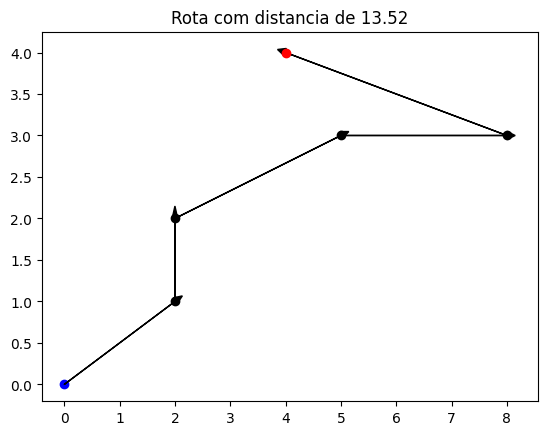

In [7]:
origem = (0,0)
destino = (4,4)

enderecos = enderecos = [(2,2), (2, 1), (5, 3), (8, 3)]

menor_rota, menor_distancia = forca_bruta(origem, destino, enderecos)
desenhar_rota(menor_rota)


In [8]:
def vizinho_mais_proximo(origem, destino, enderecos):

    ponto_atual = origem
    enderecos_restantes = enderecos.copy()

    distancia_percorrida = 0
    menor_rota = [ponto_atual]

    while len(enderecos_restantes) != 0:

        lista_distancia = [(distancia_euclidiana(ponto_atual, x), x) for x in enderecos_restantes]
        lista_distancia.sort(key=lambda item: item[0])

        ponto_mais_perto = lista_distancia[0][1]
        distancia_percorrida += lista_distancia[0][0]
        menor_rota.append(ponto_mais_perto)
        ponto_atual = ponto_mais_perto

        enderecos_restantes.remove(ponto_mais_perto)

    menor_rota.append(destino)
    distancia_percorrida += distancia_euclidiana(ponto_atual, destino)

    return menor_rota, distancia_percorrida


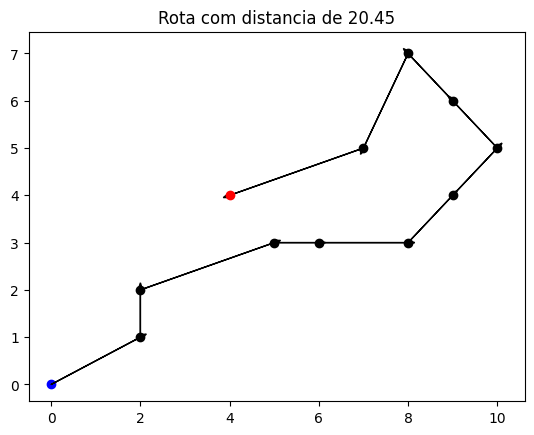

In [9]:
origem = (0,0)
destino = (4,4)

enderecos = [(2,2), (2, 1), (5, 3), (8, 3), (10, 5), (9, 4), (8, 7), (6, 3), (9, 6), (7, 5)]

menor_rota, menor_distancia = vizinho_mais_proximo(origem, destino, enderecos)
desenhar_rota(menor_rota)

In [10]:
origem = (0, 0)
destino = (4, 4)

enderecos = [(2, 2), (2, 1), (5, 3), (8, 3)]

In [11]:
def avaliar(individuo, origem, enderecos, destino):
    rota = [origem]
    for i in individuo:
        rota.append(enderecos[i])
    rota.append(destino)

    return calcular_distacia(rota), 


In [12]:
from deap import base, creator, tools, algorithms
import numpy as np

In [15]:
tam_populacao_inicial = 100 
prob_cruzamento = 0.7 
prob_mutacao = 0.1 
numero_geracoes = 100

toolbox = base.Toolbox()

creator.create("FitnessMin", base.Fitness, weights=(-1.0, ))
creator.create("Individuo", list, fitness=creator.FitnessMin)

toolbox.register("Genes", np.random.permutation, len(enderecos))
toolbox.register("Individuos", toolbox.initIterate, creator.Individuo, toolbox.Genes)

toolbox.register("Populacao", tools.initRepeat, list, toolbox.Individuos)
populacao = toolbox.Populacao(n=tam_populacao_inicial)

toolbox.register("mate", tools.cxPartialyMatched)
toolbox.register("mutate", tools.mutShuffleIndexes, indpb=prob_mutacao)
toolbox.register("select", tools.selTournament, tournsize=3)
toolbox.register("evaluate", avaliar, origem=origem, enderecos=enderecos, destino=destino)

algoritmo = algorithms.eaSimple(populacao,
                                  toolbox,
                                  cxpb=prob_cruzamento,
                                  mutpb=prob_cruzamento,
                                  ngen=numero_geracoes, 
                                  verbose=False) 
melhor_ind = tools.selBest(populacao, 1)[0]


c:\Users\leoka\AppData\Local\Programs\Python\Python311\Lib\site-packages\deap\creator.py:185: RuntimeWarning: A class named 'FitnessMin' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "
c:\Users\leoka\AppData\Local\Programs\Python\Python311\Lib\site-packages\deap\creator.py:185: RuntimeWarning: A class named 'Individuo' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "


AttributeError: 'Toolbox' object has no attribute 'initIterate'